# Saving graphs for neural-lam

From the first tagged version of [neural-lam](https://github.com/mllam/neural-lam) ([v0.1.0](https://github.com/mllam/neural-lam/tree/v0.1.0) and currently, as of `v0.4.0`) has a very specific format that the saved graphs are expected to be in based on pickled pytorch tensors. This notebook describes how to save graphs in that format and what the format is.

In [1]:
import weather_model_graphs as wmg
import numpy as np
import matplotlib.pyplot as plt
import torch
import networkx as nx

/Users/B280936/git-repos/mllam/weather-model-graphs/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


We will start by creating some a graph from some randomly generated coordinates:

In [2]:
def create_fake_irregular_coords(num_grid_points=100):
    """
    Create fake grid points on random coordinates
    """
    rng = np.random.default_rng(seed=42)  # Fixed seed
    # All coordinates in [0,1]^2
    return rng.random((num_grid_points, 2))

((0.0, 1.0), (0.0, 1.0))

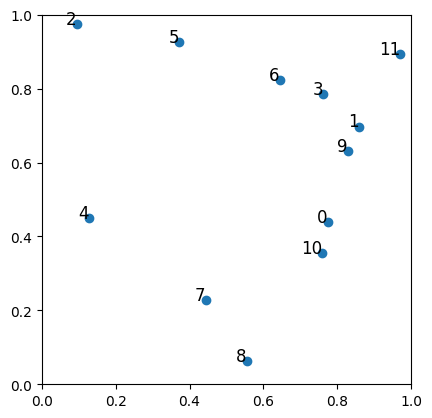

In [3]:
coords = create_fake_irregular_coords(num_grid_points=12)

fig, ax = plt.subplots()
ax.scatter(coords[:, 0], coords[:, 1])
# add labels
for i, (x, y) in enumerate(coords):
    ax.text(x, y, str(i), fontsize=12, ha="right")
ax.set_aspect("equal")
ax.set_xlim(0, 1), ax.set_ylim(0, 1)

2025-10-29 19:53:15.718 | DEBUG    | weather_model_graphs.create.base:create_all_graph_components:106 - No `coords_crs` given: Assuming `coords` contains in-projection Cartesian coordinates.


<Axes: >

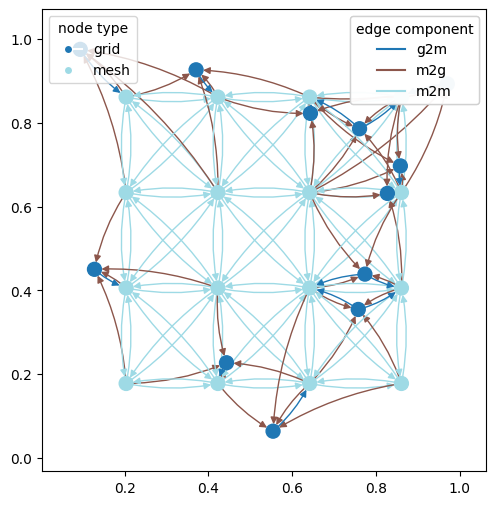

In [4]:
graph = wmg.create.archetype.create_keisler_graph(coords=coords, mesh_node_distance=0.2)

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_aspect("equal")
wmg.visualise.nx_draw_with_pos_and_attr(
    graph=graph, ax=ax, node_color_attr="type", edge_color_attr="component"
)

`neural-lam` expects the _subgraphs_ that are individually used for subsequent message passing operations to be saved separately. For the Keisler graph, this means that we need to split the graph into subgraphs that do the mesh-to-grid (`m2g`), mesh-to-mesh (`m2m`), grid-to-mesh (`g2m`), and grid-to-grid (`g2g`) operations. In `weather-model-graphs` edges have a `component` attribute that indicates which of these operations they belong to, so we can use this to split the graph.

In [5]:
subgraphs = wmg.split_graph_by_edge_attribute(graph=graph, attr="component")
subgraphs

{'m2g': <networkx.classes.digraph.DiGraph at 0x1494173e0>,
 'g2m': <networkx.classes.digraph.DiGraph at 0x14952ca70>,
 'm2m': <networkx.classes.digraph.DiGraph at 0x149635d90>}

In [6]:
outputdir = "keisler_graph_for_neural_lam"
for subgraph_name, subgraph_dict in subgraphs.items():
    wmg.save.to_pyg(subgraph_dict, output_directory=outputdir, name=subgraph_name)

! tree {outputdir}

/Users/B280936/git-repos/mllam/weather-model-graphs/.venv/lib/python3.12/site-packages/torch_geometric/utils/convert.py:278: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:256.)
  data_dict[key] = torch.as_tensor(value)
2025-10-29 19:53:15.948 | INFO     | weather_model_graphs.save:to_pyg:151 - Saved edge index to keisler_graph_for_neural_lam/m2g_edge_index.pt and features ['len', 'vdiff'] to keisler_graph_for_neural_lam/m2g_features.pt.
2025-10-29 19:53:15.948 | INFO     | weather_model_graphs.save:to_pyg:158 - Saved node features ['pos'] to keisler_graph_for_neural_lam/m2g_node_features.pt.
2025-10-29 19:53:15.950 | INFO     | weather_model_graphs.save:to_pyg:151 - Saved edge index to keisler_graph_for_neural_lam/g2m_edge_index.pt and features

keisler_graph_for_neural_lam
├── g2m_edge_index.pt
├── g2m_features.pt
├── g2m_node_features.pt
├── m2g_edge_index.pt
├── m2g_features.pt
├── m2g_node_features.pt
├── m2m_edge_index.pt
├── m2m_features.pt
└── m2m_node_features.pt

1 directory, 9 files


In [7]:
def load_nl_subgraph_format(base_path, graph_name):
    adj_list = torch.load(f"{base_path}/{graph_name}_edge_index.pt")
    edge_features = torch.load(f"{base_path}/{graph_name}_features.pt")
    node_features = torch.load(f"{base_path}/{graph_name}_node_features.pt")
    return {
        "edge_adj_list": adj_list,
        "edge_features": edge_features,
        "node_features": node_features,
    }


nl_g2m_subgraph_dict = load_nl_subgraph_format("keisler_graph_for_neural_lam", "g2m")
nl_g2m_subgraph_dict

{'edge_adj_list': tensor([[ 0,  0,  1,  2,  3,  3,  4,  5,  6,  7,  8,  9, 10, 10, 11],
         [17, 19, 20, 13, 18, 21, 12, 15, 18, 14, 16, 20, 17, 19, 21]]),
 'edge_features': tensor([[ 0.1360,  0.1320,  0.0331],
         [ 0.0933, -0.0872,  0.0331],
         [ 0.0637, -0.0025,  0.0637],
         [ 0.1581, -0.1096,  0.1140],
         [ 0.1411,  0.1191, -0.0756],
         [ 0.1253, -0.1000, -0.0756],
         [ 0.0878, -0.0756,  0.0446],
         [ 0.0834, -0.0521,  0.0651],
         [ 0.0389,  0.0019, -0.0389],
         [ 0.0535,  0.0205,  0.0494],
         [ 0.1436, -0.0874, -0.1140],
         [ 0.0336, -0.0335, -0.0020],
         [ 0.1269,  0.1161, -0.0512],
         [ 0.1151, -0.1030, -0.0512],
         [ 0.1140,  0.1096,  0.0315]]),
 'node_features': [tensor([[0.7740, 0.4389],
          [0.8586, 0.6974],
          [0.0942, 0.9756],
          [0.7611, 0.7861],
          [0.1281, 0.4504],
          [0.3708, 0.9268],
          [0.6439, 0.8228],
          [0.4434, 0.2272],
         

Let's start by looking shapes of the edge adjacency list, edge features and node features for the three subgraphs:

In [8]:
def print_shapes_of_nl_subgraphs(basedir, graph_components=["g2m", "m2m", "m2g"]):
    for component in graph_components:
        subgraph_dict = load_nl_subgraph_format(basedir, component)
        print(f"Component: {component}")
        print(f"  Edge adjacency list shape:   {subgraph_dict['edge_adj_list'].shape}")
        print(f"  Edge features shape:         {subgraph_dict['edge_features'].shape}")
        print(
            f"  Node features shape:         {[nf.shape for nf in subgraph_dict['node_features']]}"
        )
        print()


print_shapes_of_nl_subgraphs("keisler_graph_for_neural_lam")

Component: g2m
  Edge adjacency list shape:   torch.Size([2, 15])
  Edge features shape:         torch.Size([15, 3])
  Node features shape:         [torch.Size([22, 2])]

Component: m2m
  Edge adjacency list shape:   torch.Size([2, 84])
  Edge features shape:         torch.Size([84, 3])
  Node features shape:         [torch.Size([16, 2])]

Component: m2g
  Edge adjacency list shape:   torch.Size([2, 48])
  Edge features shape:         torch.Size([48, 3])
  Node features shape:         [torch.Size([28, 2])]



Next we will will construct `networkx.DiGraph` objects for each of these subgraphs so we can visualise them and check that they look correct.

In [9]:
def graph_from_nl_subgraph_format(nl_subgraph_dict):
    g = nx.DiGraph()
    edge_adj_list = nl_subgraph_dict["edge_adj_list"].numpy()
    edge_features = nl_subgraph_dict["edge_features"].numpy()
    node_features = [nf.numpy() for nf in nl_subgraph_dict["node_features"]]

    n_edges = edge_adj_list.shape[1]
    assert (
        edge_features.shape[0] == n_edges
    ), "Number of edges in adjacency list and features do not match"
    n_nodes = node_features[0].shape[0]
    assert (
        len(np.unique(edge_adj_list)) == n_nodes
    ), "Number of unique nodes in adjacency list exceeds number of node features"

    # add nodes
    for i in range(n_nodes):
        nf = node_features[0][i]
        # assume node features are [pos[0], pos[1]]
        node_pos = (nf[0], nf[1])
        g.add_node(i, pos=node_pos)

    # Add edges
    for i in range(edge_adj_list.shape[1]):
        src = int(edge_adj_list[0, i])
        dst = int(edge_adj_list[1, i])
        # assume edges features are [len, vec[0], vec[1]]
        e_features = edge_features[i]
        edge_features_named = {
            "len": float(e_features[0]),
            "vec": (float(e_features[1]), float(e_features[2])),
        }
        g.add_edge(src, dst, **edge_features_named)

    return g


nl_g2m_subgraph = graph_from_nl_subgraph_format(nl_g2m_subgraph_dict)
nl_g2m_subgraph

<Axes: >

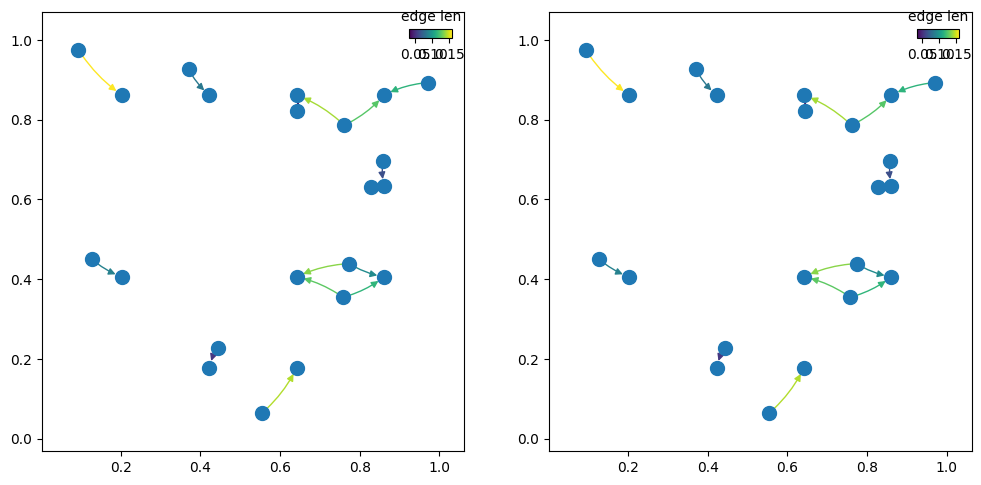

In [10]:
kwargs = dict(edge_color_attr="len")
fig, axes = plt.subplots(ncols=2, figsize=(12, 6))
[ax.set_aspect("equal") for ax in axes]
# original graph
ax = axes[0]
wmg.visualise.nx_draw_with_pos_and_attr(graph=subgraphs["g2m"], ax=ax, **kwargs)
# loaded graph
ax = axes[1]
wmg.visualise.nx_draw_with_pos_and_attr(graph=nl_g2m_subgraph, ax=ax, **kwargs)

## Assumptions in neural-lam pytorch subgraph disk format

It important to note how the *label* of nodes in `networkx.DiGraph` created by `weather-model-graphs` is used since these labels define the node-index values. In `neural-lam`, the node indices are expected to be contiguous integers starting from zero. The node labels in the `networkx.DiGraph` objects created by `weather-model-graphs` are exactly these integer indices, and writing to adjancy lists and feature tensors is done using these integer indices.


We will start by creating a plot which shows how the three subgraphs connect the mesh and grid nodes together, directly from the `networkx.DiGraph` objects we created above.

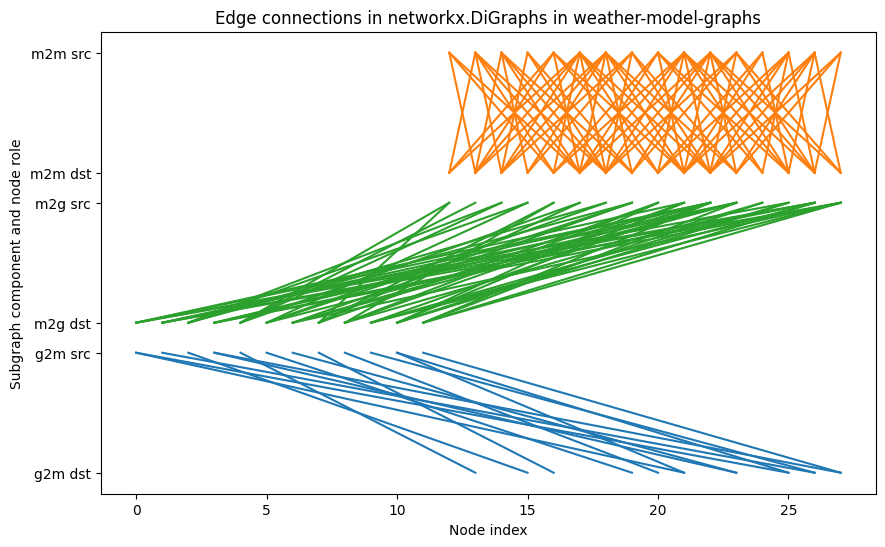

In [11]:
def plot_subgraph_edge_connections(subgraphs):

    fig, ax = plt.subplots(figsize=(10, 6))
    y_ticks = []
    y_ticklabels = []

    offset = -0.4
    colors = dict(
        g2m="C0",
        m2m="C1",
        m2g="C2",
    )
    component_names = sorted(list(subgraphs.keys()))
    for i, component in enumerate(component_names):
        color = colors[component]
        subgraph = subgraphs[component]
        edge_adj_list = np.array(subgraph.edges()).T
        ys = [i - offset, i + offset]
        ys_labels = [f"{component} src", f"{component} dst"]
        for src, dst in edge_adj_list.T:
            ax.plot([src, dst], ys, color=color)
        y_ticks += ys
        y_ticklabels += ys_labels

    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_ticklabels)
    ax.set_ylabel("Subgraph component and node role")
    ax.set_xlabel("Node index")
    ax.set_title("Edge connections in networkx.DiGraphs in weather-model-graphs")


plot_subgraph_edge_connections(subgraphs)

You can see from this plot that the node indices are ordered so that the mesh nodes come first, followed by the grid nodes. The edges in each subgraph connect the appropriate nodes together.

If we repeat this with the graphs saved into neural-lam pytorch format, we can see that there is a bug here currently in `weather-model-graphs` where the grid-to-grid subgraph is not being saved correctly. This will be fixed in a future release.

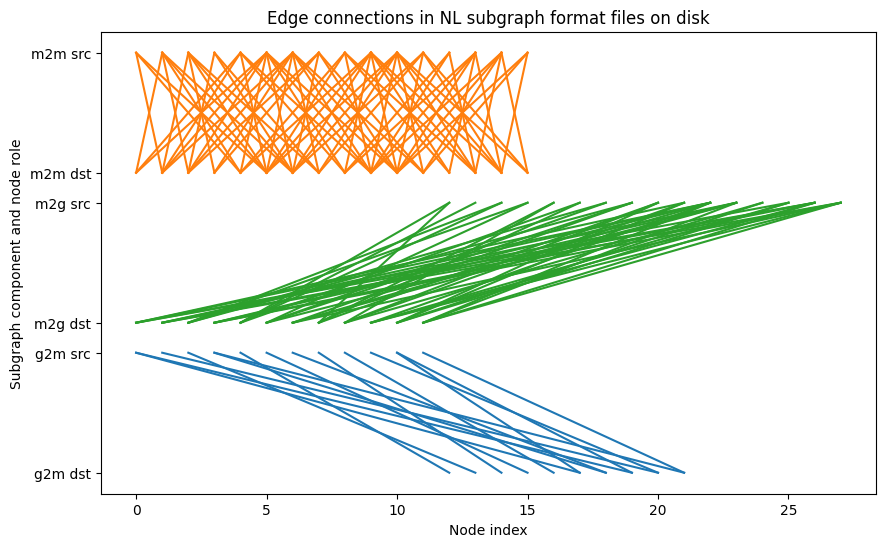

In [12]:
# create a plot where along the x-axis is the grid-index and along y-axis is
# the subgraph name, with an entry along y for both source and target nodes


def plot_nl_subgraph_edge_connections(subgraph_dicts):

    fig, ax = plt.subplots(figsize=(10, 6))
    y_ticks = []
    y_ticklabels = []

    offset = -0.4
    colors = dict(
        g2m="C0",
        m2m="C1",
        m2g="C2",
    )
    component_names = sorted(list(subgraphs.keys()))
    for i, component in enumerate(component_names):
        color = colors[component]
        subgraph_dict = subgraph_dicts[component]
        edge_adj_list = subgraph_dict["edge_adj_list"].numpy()
        ys = [i - offset, i + offset]
        ys_labels = [f"{component} src", f"{component} dst"]
        for src, dst in edge_adj_list.T:
            ax.plot([src, dst], ys, color=color)
        y_ticks += ys
        y_ticklabels += ys_labels

    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_ticklabels)
    ax.set_ylabel("Subgraph component and node role")
    ax.set_xlabel("Node index")
    ax.set_title("Edge connections in NL subgraph format files on disk")


subgraph_dicts = {
    component: load_nl_subgraph_format("keisler_graph_for_neural_lam", component)
    for component in ["g2m", "m2m", "m2g"]
}
plot_nl_subgraph_edge_connections(subgraph_dicts)

In [13]:
subgraph_dicts["m2m"]

{'edge_adj_list': tensor([[ 0,  0,  0,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  3,  3,  3,  4,  4,
           4,  4,  4,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,
           6,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,
           9, 10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 12, 12, 12, 13,
          13, 13, 13, 13, 14, 14, 14, 14, 14, 15, 15, 15],
         [ 4,  1,  5,  5,  0,  2,  6,  4,  6,  1,  3,  7,  5,  7,  2,  6,  0,  8,
           5,  9,  1,  1,  9,  4,  6,  0, 10,  2,  8,  2, 10,  5,  7,  1, 11,  3,
           9,  3, 11,  6,  2, 10,  4, 12,  9, 13,  5,  5, 13,  8, 10,  4, 14,  6,
          12,  6, 14,  9, 11,  5, 15,  7, 13,  7, 15, 10,  6, 14,  8, 13,  9,  9,
          12, 14,  8, 10, 10, 13, 15,  9, 11, 11, 14, 10]]),
 'edge_features': tensor([[ 0.2191, -0.2191,  0.0000],
         [ 0.2280,  0.0000, -0.2280],
         [ 0.3162, -0.2191, -0.2280],
         [ 0.2191, -0.2191,  0.0000],
         [ 0.2280,  0.0000,  0.2280],
